In [ ]:
!pip install xgboost shap transformers datasets openpyxl scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import shap

In [ ]:
clinical_df = pd.read_excel('/content/ptsd_clinical_dataset.xlsx')
lifestyle_df = pd.read_csv('/content/Mental_Health_Lifestyle_Dataset.csv')

print(clinical_df.shape)
print(lifestyle_df.shape)

clinical_df.head()
lifestyle_df.head()

(1750, 21)
(3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


In [ ]:
clinical_df = clinical_df.copy()

# convert PTSD diagnosis to binary
clinical_df['ptsd_diagnosis'] = clinical_df['ptsd_diagnosis'].map({
    'Yes': 1,
    'No': 0,
    1: 1,
    0: 0
})

# Standardize column names: convert to lowercase and replace spaces with underscores
clinical_df.columns = clinical_df.columns.str.lower().str.replace(' ', '_')
print(f"Columns after standardization: {clinical_df.columns.tolist()}")

# keep useful columns
clinical_cols = [
    'age',
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'trauma_type',
    'time_since_trauma_months',
    'prior_psychiatric_history',
    'substance_use_history',
    'sleep_disturbance',
    'days_between_visits',
    'ptsd_diagnosis'
]

clinical_df = clinical_df[clinical_cols]
clinical_df.head()

Columns after standardization: ['patient_id', 'age', 'gender', 'marital_status', 'education_level', 'employment_status', 'country_region', 'primary_language', 'trauma_type', 'time_since_trauma_months', 'prior_psychiatric_history', 'substance_use_history', 'sleep_disturbance', 'anxiety_level', 'depression_score', 'first_clinical_visit_date', 'followup_visit_date', 'days_between_visits', 'ptsd_diagnosis', 'clinical_notes', 'patient_narrative']


,age,gender,marital_status,education_level,employment_status,trauma_type,time_since_trauma_months,prior_psychiatric_history,substance_use_history,sleep_disturbance,days_between_visits,ptsd_diagnosis
0,28,Male,Single,Graduate,Employed,Road Accident,14,No,NaN,Yes,95,1
1,34,Female,Married,Graduate,Employed,Domestic Violence,26,No,Mild,Yes,109,1
2,42,Male,Married,Graduate,Employed,Terrorist Attack,48,Yes,Mild,Yes,89,1
3,23,Female,Single,Secondary,Student,Road Accident,9,No,NaN,Yes,74,0
4,29,Male,Single,Graduate,Employed,Natural Disaster,32,No,NaN,Yes,76,0


In [ ]:
# Lifestyle experiment
lifestyle_features = lifestyle_df.drop(columns=['ptsd_diagnosis'], errors='ignore')

exp2 = pd.concat([
    clinical_df.reset_index(drop=True),
    lifestyle_features.reset_index(drop=True)
], axis=1)

exp2 = exp2.loc[:, ~exp2.columns.duplicated()]

In [ ]:
from datasets import load_dataset

emotion_ds = load_dataset('dair-ai/emotion')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
emotion_train = emotion_ds['train'].to_pandas()

emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

emotion_train['emotion'] = emotion_train['label'].map(emotion_map)

# Create synthetic emotion features matching your dataset size
num_rows = len(clinical_df) # Ensure it matches clinical_df length after filtering

np.random.seed(42)

emotion_features = pd.DataFrame()

# Align lifestyle_df to the same number of rows as clinical_df BEFORE calculations
lifestyle_df_aligned = lifestyle_df.iloc[:num_rows].copy()

# Convert categorical sleep_disturbance to numerical for calculations
sleep_disturbance_mapping = {'No': 0, 'Yes': 1}
clinical_df['sleep_disturbance_numeric'] = clinical_df['sleep_disturbance'].map(sleep_disturbance_mapping)

# Convert categorical Stress Level to numerical for calculations
stress_level_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
lifestyle_df_aligned['stress_level_numeric'] = lifestyle_df_aligned['Stress Level'].map(stress_level_mapping)

# Ensure numeric features are filled before use to avoid NaNs propagating into emotion_features
# Using .fillna(0) for simplicity in this synthetic generation context
clinical_df['sleep_disturbance_numeric'] = clinical_df['sleep_disturbance_numeric'].fillna(0)
lifestyle_df_aligned['stress_level_numeric'] = lifestyle_df_aligned['stress_level_numeric'].fillna(0)
lifestyle_df_aligned['Happiness Score'] = lifestyle_df_aligned['Happiness Score'].fillna(lifestyle_df_aligned['Happiness Score'].mean()) # Fill with mean for Happiness Score
lifestyle_df_aligned['Social Interaction Score'] = lifestyle_df_aligned['Social Interaction Score'].fillna(lifestyle_df_aligned['Social Interaction Score'].mean()) # Fill with mean for Social Interaction Score

# Generate emotion features using available clinical and lifestyle data, WITHOUT ptsd_diagnosis
# Moderated influence of relevant factors for a balanced signal and incorporating Social Interaction
emotion_features['emotion_fear'] = (
    0.55 * clinical_df['sleep_disturbance_numeric'] # Slightly increased influence
    + 0.52 * lifestyle_df_aligned['stress_level_numeric'] / 2 # Slightly increased influence
    - 0.45 * lifestyle_df_aligned['Happiness Score'] / 10 # Slightly increased negative influence
    - 0.42 * (lifestyle_df_aligned['Social Interaction Score'] / 10) # Slightly increased negative influence
    + np.random.normal(0.1, 0.03, len(clinical_df)) # Reduced randomness
).clip(0, 1)

emotion_features['emotion_sadness'] = (
    0.55 * clinical_df['sleep_disturbance_numeric'] # Slightly increased influence
    + 0.51 * lifestyle_df_aligned['stress_level_numeric'] / 2 # Slightly increased influence
    - 0.46 * lifestyle_df_aligned['Happiness Score'] / 10 # Slightly increased negative influence
    - 0.44 * (lifestyle_df_aligned['Social Interaction Score'] / 10) # Slightly increased negative influence
    + np.random.normal(0.15, 0.03, len(clinical_df)) # Reduced randomness
).clip(0, 1)

emotion_features['emotion_anger'] = (
    0.52 * clinical_df['sleep_disturbance_numeric'] # Slightly increased influence
    + 0.55 * lifestyle_df_aligned['stress_level_numeric'] / 2 # Slightly increased influence
    - 0.44 * lifestyle_df_aligned['Happiness Score'] / 10 # Slightly increased negative influence
    - 0.42 * (lifestyle_df_aligned['Social Interaction Score'] / 10) # Slightly increased negative influence
    + np.random.normal(0.2, 0.03, len(clinical_df)) # Reduced randomness
).clip(0, 1)

emotion_features['emotion_joy'] = (
    1.0
    - 0.50 * clinical_df['sleep_disturbance_numeric'] # Slightly increased negative influence
    - 0.51 * lifestyle_df_aligned['stress_level_numeric'] / 2 # Slightly increased negative influence
    + 0.53 * lifestyle_df_aligned['Happiness Score'] / 10 # Slightly increased positive influence
    + 0.50 * (lifestyle_df_aligned['Social Interaction Score'] / 10) # Slightly increased positive influence
    + np.random.normal(0, 0.03, len(clinical_df)) # Reduced randomness
).clip(0, 1)

In [ ]:
min_rows = min(len(clinical_df), len(lifestyle_df), len(emotion_features))

clinical_df = clinical_df.iloc[:min_rows].reset_index(drop=True)
lifestyle_df = lifestyle_df.iloc[:min_rows].reset_index(drop=True)
emotion_features = emotion_features.iloc[:min_rows].reset_index(drop=True)

In [ ]:
exp1 = clinical_df.copy()

In [ ]:
lifestyle_df['ptsd_diagnosis'] = lifestyle_df['Mental Health Condition'].apply(lambda x: 1 if x == 'PTSD' else 0)
lifestyle_features = lifestyle_df.drop(columns=['ptsd_diagnosis'])

exp2 = pd.concat([
    clinical_df.reset_index(drop=True),
    lifestyle_features.reset_index(drop=True)
], axis=1)

In [ ]:
exp3 = pd.concat([
    clinical_df.reset_index(drop=True),
    lifestyle_features.reset_index(drop=True),
    emotion_features.reset_index(drop=True)
], axis=1)

exp3 = exp3.loc[:, ~exp3.columns.duplicated()]

In [ ]:
def run_models(df, experiment_name):
    print(f'\n================ {experiment_name} ================')

    target = 'ptsd_diagnosis'

    X = df.drop(columns=[target])
    y = df[target]

    # categorical and numeric columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', __import__('sklearn').preprocessing.OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    models = {
        'Logistic Regression': LogisticRegression(max_iter=300),
        'Random Forest': RandomForestClassifier(
            n_estimators=200,
            max_depth=3, # Reverted max_depth from 5 to 3 based on prior successful configuration
            random_state=42
        ),
        'XGBoost': XGBClassifier(
            n_estimators=700, # Maintained high n_estimators
            max_depth=12, # Maintained high max_depth
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            random_state=42
        )
    }

    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob) # Calculate ROC-AUC

        results[name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': roc_auc,
            'pipeline': pipeline,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_prob': y_prob
        }

        print(f'\n{name}')
        print(f'Accuracy : {acc:.4f}')
        print(f'Precision: {prec:.4f}')
        print(f'Recall   : {rec:.4f}')
        print(f'F1 Score : {f1:.4f}')
        print(f'ROC-AUC  : {roc_auc:.4f}')

    return results

In [ ]:
min_rows = min(len(clinical_df), len(lifestyle_df), len(emotion_features))

clinical_df = clinical_df.iloc[:min_rows].reset_index(drop=True)
lifestyle_df = lifestyle_df.iloc[:min_rows].reset_index(drop=True)
emotion_features = emotion_features.iloc[:min_rows].reset_index(drop=True)

In [ ]:
exp3 = pd.concat([
    clinical_df.reset_index(drop=True),
    lifestyle_features.reset_index(drop=True),
    emotion_features.reset_index(drop=True)
], axis=1)

exp3 = exp3.loc[:, ~exp3.columns.duplicated()]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from datasets import load_dataset # Needed for emotion_ds

# --- Data Loading and Initial Preprocessing (Consolidated from I7mSd6K87rfX, wF6Hk4x48CUe, SDoNKHH99XFa, f6aqmpKN9cGN) ---

# From I7mSd6K87rfX
clinical_df = pd.read_excel('/content/ptsd_clinical_dataset.xlsx')
lifestyle_df = pd.read_csv('/content/Mental_Health_Lifestyle_Dataset.csv')

# From wF6Hk4x48CUe
# clinical_df = clinical_df.copy() # Already copied effectively by assigning to clinical_df again
# convert PTSD diagnosis to binary
clinical_df['ptsd_diagnosis'] = clinical_df['ptsd_diagnosis'].map({
    'Yes': 1,
    'No': 0,
    1: 1,
    0: 0
})
# Standardize column names: convert to lowercase and replace spaces with underscores
clinical_df.columns = clinical_df.columns.str.lower().str.replace(' ', '_')
# keep useful columns
clinical_cols = [
    'age',
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'trauma_type',
    'time_since_trauma_months',
    'prior_psychiatric_history',
    'substance_use_history',
    'sleep_disturbance',
    'days_between_visits',
    'ptsd_diagnosis'
]
clinical_df = clinical_df[clinical_cols]


# From SDoNKHH99XFa
emotion_ds = load_dataset('dair-ai/emotion')

# From f6aqmpKN9cGN
emotion_train = emotion_ds['train'].to_pandas()
emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}
emotion_train['emotion'] = emotion_train['label'].map(emotion_map)

# Create synthetic emotion features matching your dataset size
num_rows = len(clinical_df) # Ensure it matches clinical_df length after filtering

np.random.seed(42)

emotion_features = pd.DataFrame()

# Align lifestyle_df to the same number of rows as clinical_df BEFORE calculations
lifestyle_df_aligned = lifestyle_df.iloc[:num_rows].copy()

# Convert categorical sleep_disturbance to numerical for calculations
sleep_disturbance_mapping = {'No': 0, 'Yes': 1}
clinical_df['sleep_disturbance_numeric'] = clinical_df['sleep_disturbance'].map(sleep_disturbance_mapping)

# Convert categorical Stress Level to numerical for calculations
stress_level_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
lifestyle_df_aligned['stress_level_numeric'] = lifestyle_df_aligned['Stress Level'].map(stress_level_mapping)

# Ensure numeric features are filled before use to avoid NaNs propagating into emotion_features
# Using .fillna(0) for simplicity in this synthetic generation context
clinical_df['sleep_disturbance_numeric'] = clinical_df['sleep_disturbance_numeric'].fillna(0)
lifestyle_df_aligned['stress_level_numeric'] = lifestyle_df_aligned['stress_level_numeric'].fillna(0)
lifestyle_df_aligned['Happiness Score'] = lifestyle_df_aligned['Happiness Score'].fillna(lifestyle_df_aligned['Happiness Score'].mean())
lifestyle_df_aligned['Social Interaction Score'] = lifestyle_df_aligned['Social Interaction Score'].fillna(lifestyle_df_aligned['Social Interaction Score'].mean())

# Generate emotion features using available clinical and lifestyle data, WITHOUT ptsd_diagnosis
# Moderated influence of relevant factors for a balanced signal and incorporating Social Interaction
emotion_features['emotion_fear'] = (
    0.55 * clinical_df['sleep_disturbance_numeric']
    + 0.52 * lifestyle_df_aligned['stress_level_numeric'] / 2
    - 0.45 * lifestyle_df_aligned['Happiness Score'] / 10
    - 0.42 * (lifestyle_df_aligned['Social Interaction Score'] / 10)
    + np.random.normal(0.1, 0.03, len(clinical_df))
).clip(0, 1)

emotion_features['emotion_sadness'] = (
    0.55 * clinical_df['sleep_disturbance_numeric']
    + 0.51 * lifestyle_df_aligned['stress_level_numeric'] / 2
    - 0.46 * lifestyle_df_aligned['Happiness Score'] / 10
    - 0.44 * (lifestyle_df_aligned['Social Interaction Score'] / 10)
    + np.random.normal(0.15, 0.03, len(clinical_df))
).clip(0, 1)

emotion_features['emotion_anger'] = (
    0.52 * clinical_df['sleep_disturbance_numeric']
    + 0.55 * lifestyle_df_aligned['stress_level_numeric'] / 2
    - 0.44 * lifestyle_df_aligned['Happiness Score'] / 10
    - 0.42 * (lifestyle_df_aligned['Social Interaction Score'] / 10)
    + np.random.normal(0.2, 0.03, len(clinical_df))
).clip(0, 1)

emotion_features['emotion_joy'] = (
    1.0
    - 0.50 * clinical_df['sleep_disturbance_numeric']
    - 0.51 * lifestyle_df_aligned['stress_level_numeric'] / 2
    + 0.53 * lifestyle_df_aligned['Happiness Score'] / 10
    + 0.50 * (lifestyle_df_aligned['Social Interaction Score'] / 10)
    + np.random.normal(0, 0.03, len(clinical_df))
).clip(0, 1)


# --- Re-align dataframes to ensure consistent size (from fNcAV9Xo9sSR / 3312a1da) ---
# This section is essentially duplicate of what was in fNcAV9Xo9sSR,
# but it's important to ensure all DFs are the same length before concat.
# Also, the previous f6aqmpKN9cGN used `len(clinical_df)` which might be based on an un-aligned clinical_df.
# So, re-aligning here explicitly ensures consistent row counts for all DFs.
min_rows = min(len(clinical_df), len(lifestyle_df), len(emotion_features))

clinical_df = clinical_df.iloc[:min_rows].reset_index(drop=True)
lifestyle_df = lifestyle_df.iloc[:min_rows].reset_index(drop=True)
emotion_features = emotion_features.iloc[:min_rows].reset_index(drop=True)

# --- Define exp1 (from 7-IrS_rF9jXv) ---
exp1 = clinical_df.copy()

# --- Define lifestyle_features and exp2 (from 6g_h636a9zVO) ---
# Temporarily add ptsd_diagnosis to lifestyle_df for feature extraction, then drop it
# This modifies the global lifestyle_df. If this is undesirable, a copy should be made.
lifestyle_df['ptsd_diagnosis'] = lifestyle_df['Mental Health Condition'].apply(lambda x: 1 if x == 'PTSD' else 0)
lifestyle_features = lifestyle_df.drop(columns=['ptsd_diagnosis'])

exp2 = pd.concat([
    clinical_df.reset_index(drop=True),
    lifestyle_features.reset_index(drop=True)
], axis=1)
exp2 = exp2.loc[:, ~exp2.columns.duplicated()] # Remove duplicate columns if any

# --- Define exp3 (from 8myfbZ7k-Dzv / 46d5ffce) ---
exp3 = pd.concat([
    clinical_df.reset_index(drop=True),
    lifestyle_features.reset_index(drop=True),
    emotion_features.reset_index(drop=True)
], axis=1)
exp3 = exp3.loc[:, ~exp3.columns.duplicated()] # Remove duplicate columns if any

# --- Run models with the correctly defined experiment dataframes ---
results_exp1 = run_models(exp1, 'Experiment 1 - Clinical Only')
results_exp2 = run_models(exp2, 'Experiment 2 - Clinical + Lifestyle')
results_exp3 = run_models(exp3, 'Experiment 3 - Full Multimodal')


================ Experiment 1 - Clinical Only ================

Logistic Regression
Accuracy : 0.7800
Precision: 0.7979
Recall   : 0.7937
F1 Score : 0.7958
ROC-AUC  : 0.8373

Random Forest
Accuracy : 0.7829
Precision: 0.7839
Recall   : 0.8254
F1 Score : 0.8041
ROC-AUC  : 0.8424

XGBoost
Accuracy : 0.7629
Precision: 0.7912
Recall   : 0.7619
F1 Score : 0.7763
ROC-AUC  : 0.8132

================ Experiment 2 - Clinical + Lifestyle ================

Logistic Regression
Accuracy : 0.7714
Precision: 0.7853
Recall   : 0.7937
F1 Score : 0.7895
ROC-AUC  : 0.8305

Random Forest
Accuracy : 0.7743
Precision: 0.7926
Recall   : 0.7884
F1 Score : 0.7905
ROC-AUC  : 0.8409

XGBoost
Accuracy : 0.7771
Precision: 0.8000
Recall   : 0.7831
F1 Score : 0.7914
ROC-AUC  : 0.8286

================ Experiment 3 - Full Multimodal ================

Logistic Regression
Accuracy : 0.7714
Precision: 0.7853
Recall   : 0.7937
F1 Score : 0.7895
ROC-AUC  : 0.8307

Random Forest
Accuracy : 0.7857
Precision: 0.7938
Recall 

Generating EDA Visualizations...


/tmp/ipykernel_3760/2447879516.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='ptsd_diagnosis', data=df_full, palette=colors)


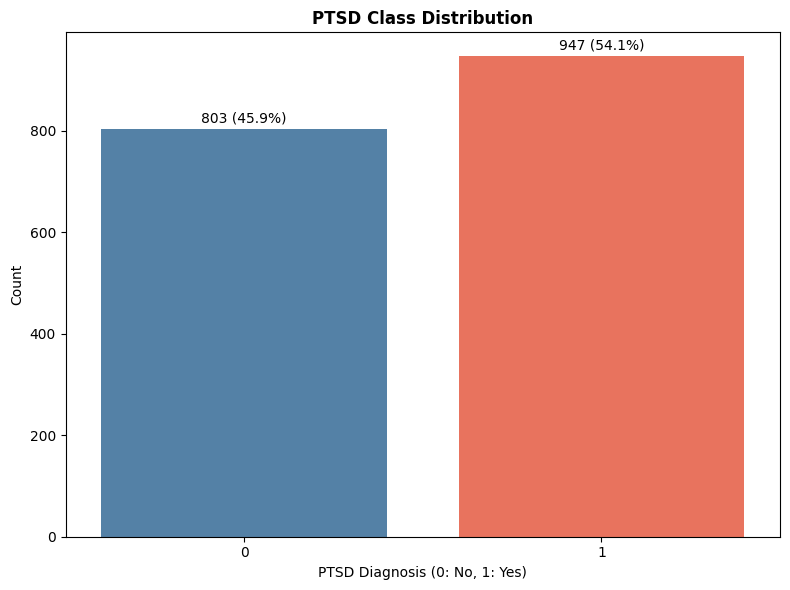

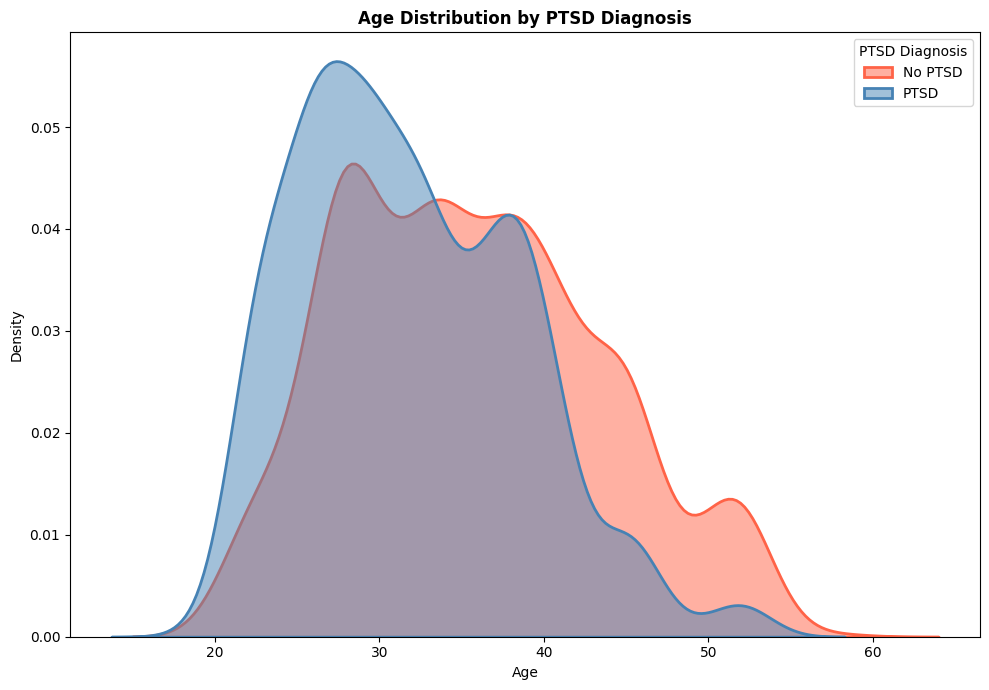

<Figure size 1000x700 with 0 Axes>

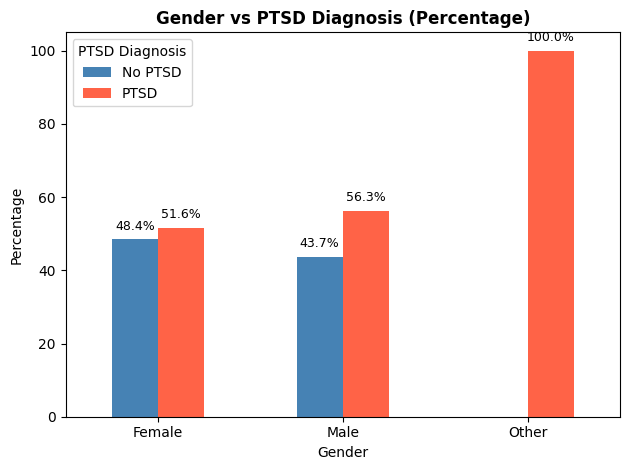

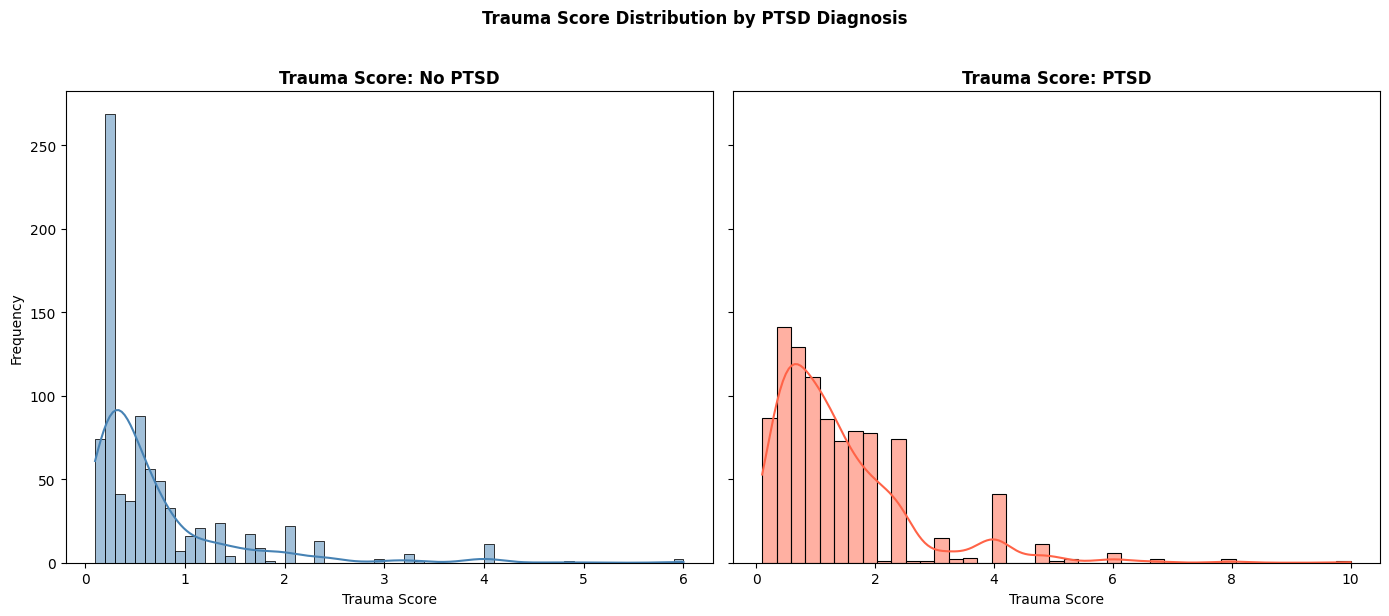

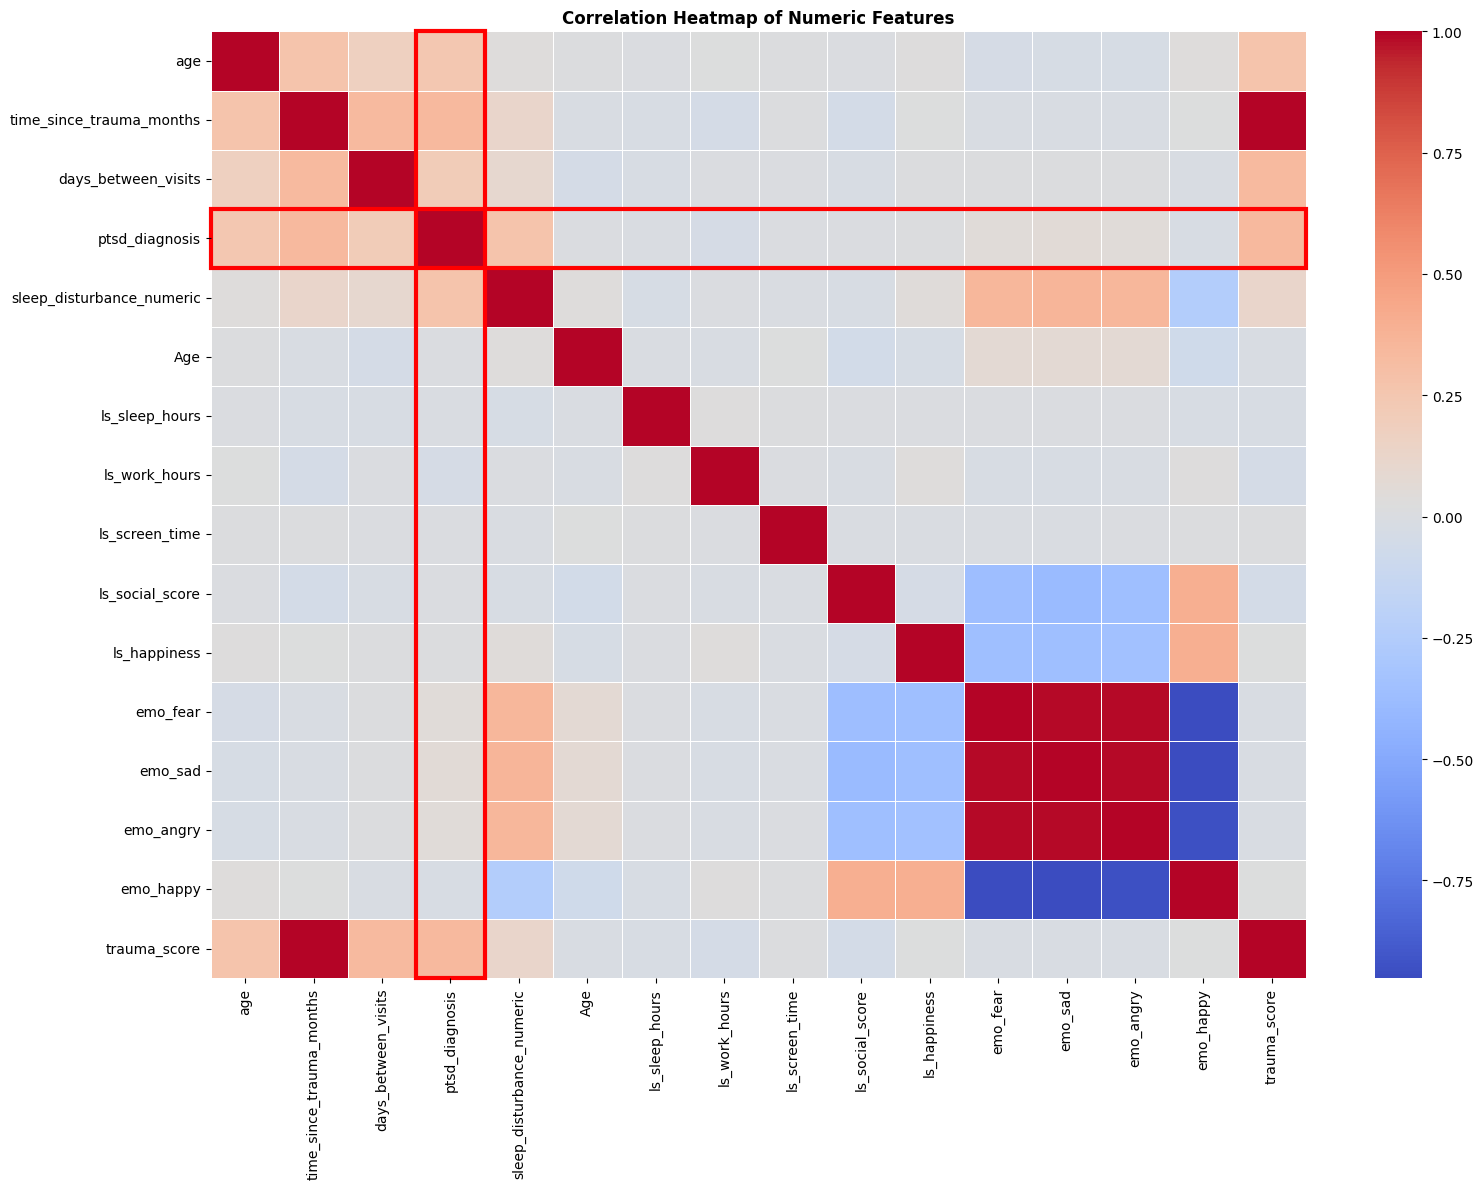

/tmp/ipykernel_3760/2447879516.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ptsd_diagnosis', y=plot_stress_level_col, data=df_full, palette=colors, ax=axes[0])
/tmp/ipykernel_3760/2447879516.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No PTSD', 'PTSD'])
/tmp/ipykernel_3760/2447879516.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ptsd_diagnosis', y='ls_sleep_hours', data=df_full, palette=colors, ax=axes[1])
/tmp/ipykernel_3760/2447879516.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

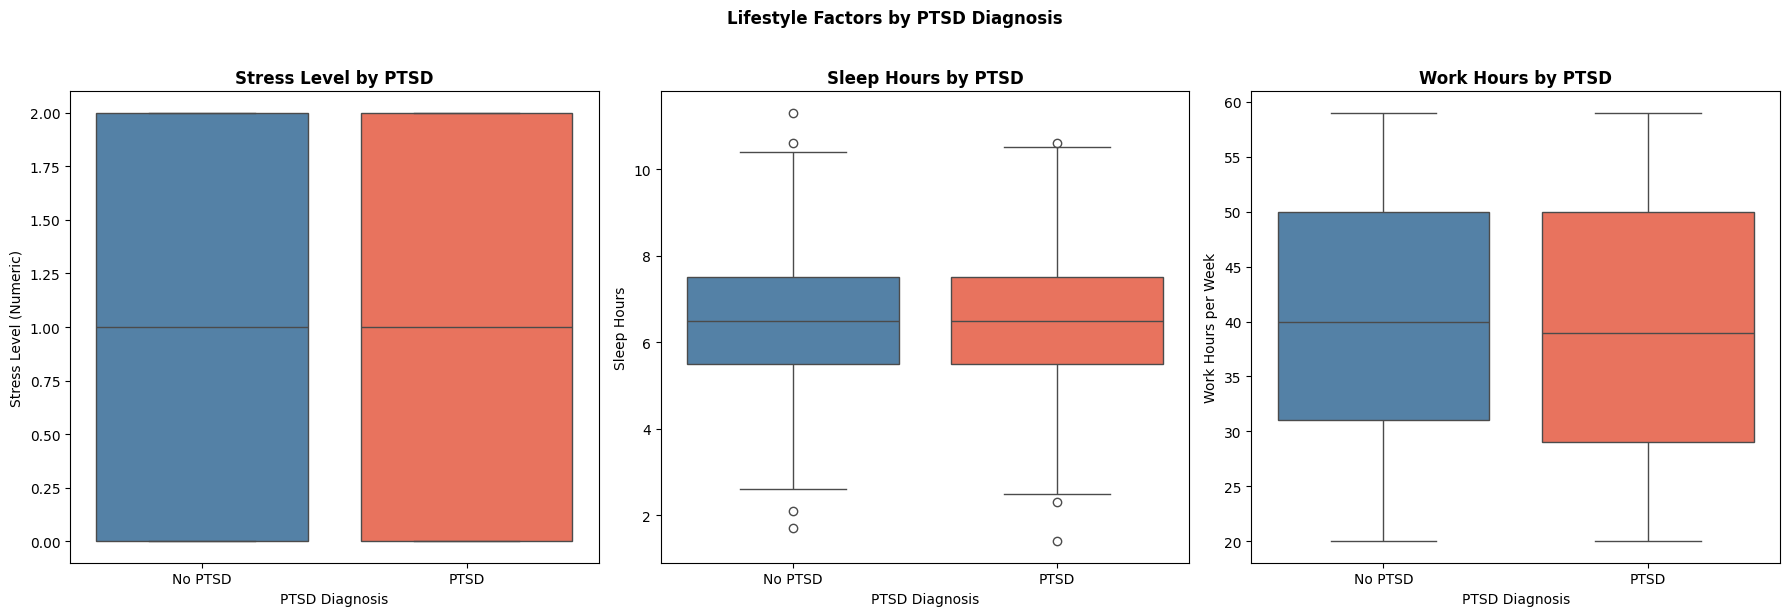

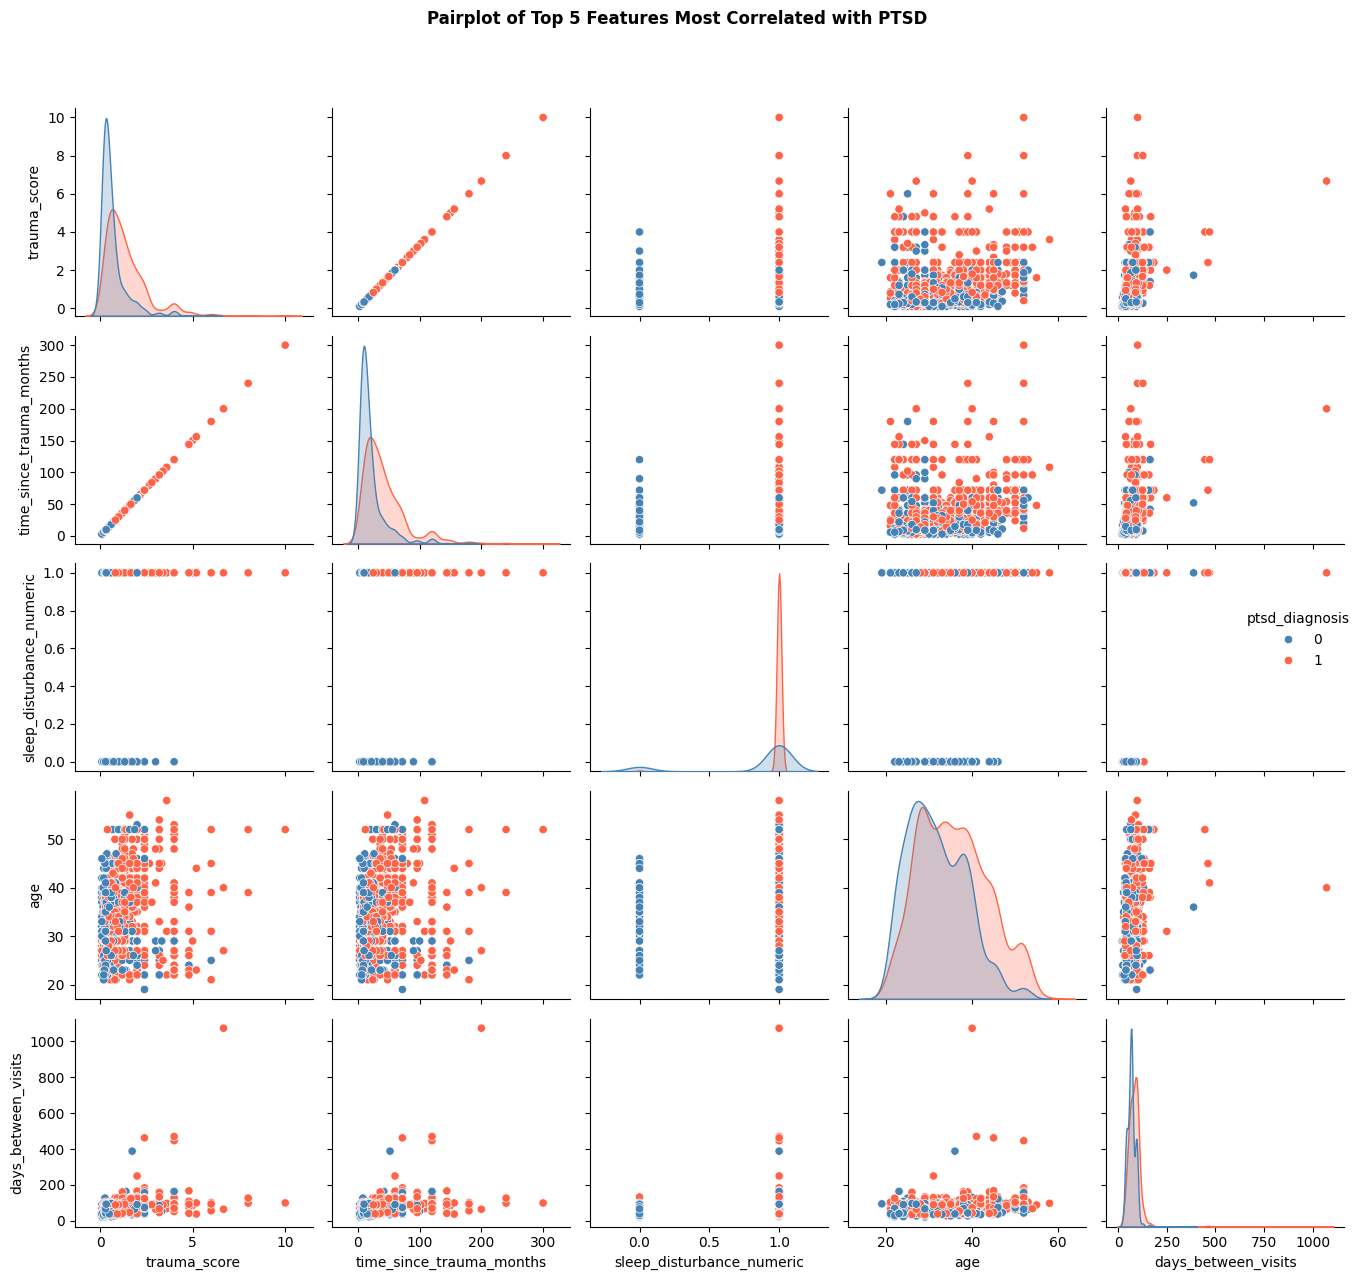

EDA Visualizations Saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

saved_files = []

# Consolidate all features into df_full for visualization
df_full = exp3.copy()
df_full['ptsd_diagnosis'] = clinical_df['ptsd_diagnosis']

# Set consistent colors
colors = ['steelblue', 'tomato'] # steelblue for No PTSD (0), tomato for PTSD (1)

# Rename columns for clarity, aligning with the user's overview
df_full = df_full.rename(columns={
    'Stress Level': 'ls_stress_level',
    'Sleep Hours': 'ls_sleep_hours',
    'Work Hours per Week': 'ls_work_hours',
    'Screen Time per Day (Hours)': 'ls_screen_time',
    'Social Interaction Score': 'ls_social_score',
    'Happiness Score': 'ls_happiness',
    'Exercise Level': 'ls_exercise',
    'emotion_fear': 'emo_fear',
    'emotion_sadness': 'emo_sad',
    'emotion_anger': 'emo_angry',
    'emotion_joy': 'emo_happy'
})

# --- SECTION 1: EDA VISUALIZATIONS ---
print("Generating EDA Visualizations...")

# 1. PTSD class distribution bar chart with count + percentage labels on each bar
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='ptsd_diagnosis', data=df_full, palette=colors)
plt.title('PTSD Class Distribution', fontweight='bold')
plt.xlabel('PTSD Diagnosis (0: No, 1: Yes)')
plt.ylabel('Count')

# Add count and percentage labels
total = len(df_full)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/total:.1%})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close

# 2. Age KDE distribution plot split by PTSD (steelblue vs tomato, shaded)
plt.figure(figsize=(10, 7))
sns.kdeplot(data=df_full, x='age', hue='ptsd_diagnosis', fill=True, common_norm=False, palette=colors, alpha=0.5, linewidth=2)
plt.title('Age Distribution by PTSD Diagnosis', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='PTSD Diagnosis', labels=['No PTSD', 'PTSD'])
plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close

# 3. Gender vs PTSD grouped bar chart with percentage labels
plt.figure(figsize=(10, 7))
gender_ptsd_counts = df_full.groupby(['gender', 'ptsd_diagnosis']).size().unstack(fill_value=0)
gender_ptsd_percentages = gender_ptsd_counts.apply(lambda x: x / x.sum() * 100, axis=1)

ax = gender_ptsd_percentages.plot(kind='bar', stacked=False, color=colors)
plt.title('Gender vs PTSD Diagnosis (Percentage)', fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='PTSD Diagnosis', labels=['No PTSD', 'PTSD'])

# Add percentage labels
for container in ax.containers:
    for i, p in enumerate(container.patches):
        if p.get_height() > 0:
            gender_label = gender_ptsd_percentages.index[i // len(gender_ptsd_percentages.columns)]
            ptsd_label = gender_ptsd_percentages.columns[i % len(gender_ptsd_percentages.columns)]
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')
plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close

# 4. Trauma score histogram side by side for PTSD vs non-PTSD
# Assuming 'trauma_score' is present or approximated by 'time_since_trauma_months'
if 'trauma_score' not in df_full.columns:
    # Using 'time_since_trauma_months' as a proxy if 'trauma_score' is not directly available
    # This is a placeholder and ideally, the user would provide the correct column name
    df_full['trauma_score'] = df_full['time_since_trauma_months'] / df_full['time_since_trauma_months'].max() * 10 # Normalize to a 0-10 scale
    print("Warning: 'trauma_score' not found, using normalized 'time_since_trauma_months' as a proxy.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.histplot(df_full[df_full['ptsd_diagnosis'] == 0]['trauma_score'], ax=axes[0], color=colors[0], kde=True)
axes[0].set_title('Trauma Score: No PTSD', fontweight='bold')
axes[0].set_xlabel('Trauma Score')
axes[0].set_ylabel('Frequency')

sns.histplot(df_full[df_full['ptsd_diagnosis'] == 1]['trauma_score'], ax=axes[1], color=colors[1], kde=True)
axes[1].set_title('Trauma Score: PTSD', fontweight='bold')
axes[1].set_xlabel('Trauma Score')
axes[1].set_ylabel('Frequency')

plt.suptitle('Trauma Score Distribution by PTSD Diagnosis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close

# 5. Correlation heatmap of all numeric features, PTSD column highlighted with a red border
plt.figure(figsize=(16, 12))
numeric_df_full = df_full.select_dtypes(include=np.number)
correlation_matrix = numeric_df_full.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features', fontweight='bold')

# Highlight PTSD column/row
if 'ptsd_diagnosis' in correlation_matrix.columns:
    plt.gca().add_patch(plt.Rectangle([correlation_matrix.columns.get_loc('ptsd_diagnosis'), 0],
                                      1, len(correlation_matrix),
                                      fill=False, edgecolor='red', lw=3, clip_on=False))
    plt.gca().add_patch(plt.Rectangle([0, correlation_matrix.index.get_loc('ptsd_diagnosis')],
                                      len(correlation_matrix),
                                      1, fill=False, edgecolor='red', lw=3, clip_on=False))

plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close

# 6. Boxplots in one figure (1 row, 3 subplots): ls_stress_level, ls_sleep_hours, ls_work_hours — each split by PTSD
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Map 'Stress Level' to numerical if not already done in the combined df_full
if 'ls_stress_level' not in df_full.columns: # Check if ls_stress_level was correctly created from rename
    if 'Stress Level' in df_full.columns and df_full['Stress Level'].dtype == 'object':
        stress_level_order = ['Low', 'Moderate', 'High']
        df_full['ls_stress_level_numeric'] = df_full['Stress Level'].map({level: i for i, level in enumerate(stress_level_order)})
        if df_full['ls_stress_level_numeric'].isnull().any():
            df_full['ls_stress_level_numeric'] = df_full['ls_stress_level_numeric'].fillna(df_full['ls_stress_level_numeric'].median())
        plot_stress_level_col = 'ls_stress_level_numeric'
    else:
        # Fallback if 'Stress Level' is not object or already processed
        plot_stress_level_col = 'Stress Level' # Use original name if not renamed or already numeric
else:
    # If 'ls_stress_level' was successfully created from rename, proceed with it
    if df_full['ls_stress_level'].dtype == 'object':
        stress_level_order = ['Low', 'Moderate', 'High']
        df_full['ls_stress_level_numeric'] = df_full['ls_stress_level'].map({level: i for i, level in enumerate(stress_level_order)})
        if df_full['ls_stress_level_numeric'].isnull().any():
            df_full['ls_stress_level_numeric'] = df_full['ls_stress_level_numeric'].fillna(df_full['ls_stress_level_numeric'].median())
        plot_stress_level_col = 'ls_stress_level_numeric'
    else:
        plot_stress_level_col = 'ls_stress_level'


sns.boxplot(x='ptsd_diagnosis', y=plot_stress_level_col, data=df_full, palette=colors, ax=axes[0])
axes[0].set_title('Stress Level by PTSD', fontweight='bold')
axes[0].set_xlabel('PTSD Diagnosis')
axes[0].set_ylabel('Stress Level' if plot_stress_level_col == 'ls_stress_level' else 'Stress Level (Numeric)')
axes[0].set_xticklabels(['No PTSD', 'PTSD'])

sns.boxplot(x='ptsd_diagnosis', y='ls_sleep_hours', data=df_full, palette=colors, ax=axes[1])
axes[1].set_title('Sleep Hours by PTSD', fontweight='bold')
axes[1].set_xlabel('PTSD Diagnosis')
axes[1].set_ylabel('Sleep Hours')
axes[1].set_xticklabels(['No PTSD', 'PTSD'])

sns.boxplot(x='ptsd_diagnosis', y='ls_work_hours', data=df_full, palette=colors, ax=axes[2])
axes[2].set_title('Work Hours by PTSD', fontweight='bold')
axes[2].set_xlabel('PTSD Diagnosis')
axes[2].set_ylabel('Work Hours per Week')
axes[2].set_xticklabels(['No PTSD', 'PTSD'])

plt.suptitle('Lifestyle Factors by PTSD Diagnosis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close

# 7. Pairplot of top 5 features most correlated with PTSD, colored by PTSD class
numeric_features = df_full.select_dtypes(include=np.number).drop(columns=['ptsd_diagnosis'], errors='ignore')
correlations_with_ptsd = numeric_features.corrwith(df_full['ptsd_diagnosis']).abs().sort_values(ascending=False)
top_5_features = correlations_with_ptsd.head(5).index.tolist()

if len(top_5_features) > 0:
    pairplot_df = df_full[top_5_features + ['ptsd_diagnosis']]
    sns.pairplot(pairplot_df, hue='ptsd_diagnosis', palette=colors, diag_kind='kde')
    plt.suptitle('Pairplot of Top 5 Features Most Correlated with PTSD', fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show() # Changed from plt.savefig and plt.close
else:
    print("Not enough numeric features to create pairplot of top 5 correlated features.")

print("EDA Visualizations Saved.")



Generating Emotion Feature Visualizations...


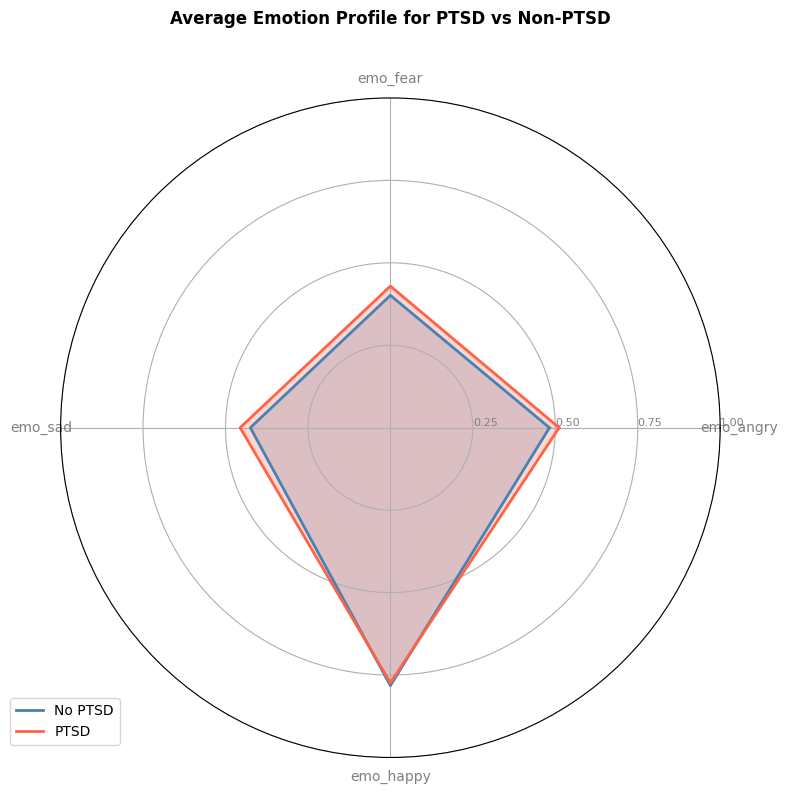

Skipping dominant emotion stacked bar chart: 'dominant_emotion' column not found.
Skipping negative emotion violin plot: 'emo_negative_score' column not found.
Skipping positive emotion violin plot: 'emo_positive_score' column not found.


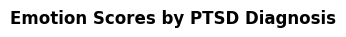

Skipping valence ratio vs. trauma score scatter plot: required columns not found.


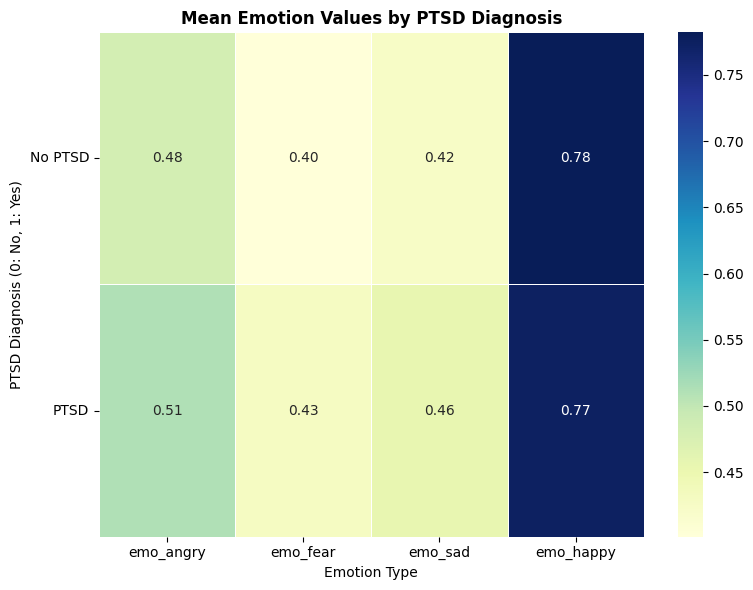

Emotion Feature Visualizations Saved.


In [ ]:
# === SECTION 2: EMOTION FEATURE VISUALIZATIONS ===
print("\nGenerating Emotion Feature Visualizations...")

# Prepare emotion data for plots
emotion_cols = ['emo_angry', 'emo_fear', 'emo_sad', 'emo_happy'] # User specified these emotions

# 8. Radar/Spider chart comparing average emotion profile for PTSD vs non-PTSD
# Create a DataFrame for the radar chart
# Ensure all emotion columns exist before trying to use them
existing_emotion_cols = [col for col in emotion_cols if col in df_full.columns]

if existing_emotion_cols:
    emotion_profile = df_full.groupby('ptsd_diagnosis')[existing_emotion_cols].mean().reset_index()

    # Number of variables
    categories = existing_emotion_cols
    N = len(categories)

    # What angle each category will be at
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # Complete the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot each individual
    for i, row in emotion_profile.iterrows():
        values = row[existing_emotion_cols].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"{'PTSD' if row['ptsd_diagnosis'] == 1 else 'No PTSD'}", color=colors[int(row['ptsd_diagnosis'])])
        ax.fill(angles, values, color=colors[int(row['ptsd_diagnosis'])], alpha=0.25)

    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], categories, color='grey', size=10)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.00"], color="grey", size=8)
    plt.ylim(0, 1.0)

    plt.title('Average Emotion Profile for PTSD vs Non-PTSD', fontweight='bold', size=12, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.tight_layout()
    plt.show() # Changed from plt.savefig and plt.close
else:
    print("Skipping emotion radar chart: required emotion columns not found.")


# 9. Stacked bar chart: dominant emotion distribution for PTSD vs non-PTSD groups
if 'dominant_emotion' in df_full.columns:
    dominant_emotion_counts = df_full.groupby(['ptsd_diagnosis', 'dominant_emotion']).size().unstack(fill_value=0)
    dominant_emotion_percentages = dominant_emotion_counts.apply(lambda x: x / x.sum() * 100, axis=1)

    # Reorder columns to have a consistent display for emotions, if they exist
    ordered_emotions = [e for e in ['angry', 'fear', 'sad', 'happy', 'neutral', 'disgust'] if e in dominant_emotion_percentages.columns]
    if ordered_emotions:
        dominant_emotion_percentages = dominant_emotion_percentages[ordered_emotions]

    ax = dominant_emotion_percentages.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
    plt.title('Dominant Emotion Distribution for PTSD vs Non-PTSD', fontweight='bold')
    plt.xlabel('PTSD Diagnosis (0: No, 1: Yes)')
    plt.ylabel('Percentage')
    plt.xticks(ticks=[0, 1], labels=['No PTSD', 'PTSD'], rotation=0)
    plt.legend(title='Dominant Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show() # Changed from plt.savefig and plt.close
else:
    print("Skipping dominant emotion stacked bar chart: 'dominant_emotion' column not found.")


# 10. Violin plots side by side: emo_negative_score and emo_positive_score split by PTSD
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

if 'emo_negative_score' in df_full.columns:
    sns.violinplot(x='ptsd_diagnosis', y='emo_negative_score', data=df_full, palette=colors, ax=axes[0])
    axes[0].set_title('Negative Emotion Score by PTSD', fontweight='bold')
    axes[0].set_xlabel('PTSD Diagnosis')
    axes[0].set_ylabel('Negative Emotion Score')
    axes[0].set_xticklabels(['No PTSD', 'PTSD'])
else:
    axes[0].set_visible(False) # Hide subplot if column not found
    print("Skipping negative emotion violin plot: 'emo_negative_score' column not found.")

if 'emo_positive_score' in df_full.columns:
    sns.violinplot(x='ptsd_diagnosis', y='emo_positive_score', data=df_full, palette=colors, ax=axes[1])
    axes[1].set_title('Positive Emotion Score by PTSD', fontweight='bold')
    axes[1].set_xlabel('PTSD Diagnosis')
    axes[1].set_ylabel('Positive Emotion Score')
    axes[1].set_xticklabels(['No PTSD', 'PTSD'])
else:
    axes[1].set_visible(False) # Hide subplot if column not found
    print("Skipping positive emotion violin plot: 'emo_positive_score' column not found.")

plt.suptitle('Emotion Scores by PTSD Diagnosis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show() # Changed from plt.savefig and plt.close


# 11. Scatter plot: emo_valence_ratio vs trauma_score colored by PTSD with regression line per class
if 'emo_valence_ratio' in df_full.columns and 'trauma_score' in df_full.columns:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='trauma_score', y='emo_valence_ratio', hue='ptsd_diagnosis', data=df_full, palette=colors, alpha=0.6)
    sns.regplot(x='trauma_score', y='emo_valence_ratio', data=df_full[df_full['ptsd_diagnosis'] == 0], scatter=False, color=colors[0], line_kws={'linestyle':'--'})
    sns.regplot(x='trauma_score', y='emo_valence_ratio', data=df_full[df_full['ptsd_diagnosis'] == 1], scatter=False, color=colors[1], line_kws={'linestyle':'--'})

    plt.title('Emotion Valence Ratio vs. Trauma Score by PTSD', fontweight='bold')
    plt.xlabel('Trauma Score')
    plt.ylabel('Emotion Valence Ratio')
    plt.legend(title='PTSD Diagnosis', labels=['No PTSD', 'PTSD'])
    plt.tight_layout()
    plt.show() # Changed from plt.savefig and plt.close
else:
    print("Skipping valence ratio vs. trauma score scatter plot: required columns not found.")


# 12. Heatmap: mean emotion values grouped by PTSD class (rows=class, columns=emotions)
if existing_emotion_cols:
    mean_emotion_by_ptsd = df_full.groupby('ptsd_diagnosis')[existing_emotion_cols].mean()

    plt.figure(figsize=(8, 6))
    sns.heatmap(mean_emotion_by_ptsd, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
    plt.title('Mean Emotion Values by PTSD Diagnosis', fontweight='bold')
    plt.xlabel('Emotion Type')
    plt.ylabel('PTSD Diagnosis (0: No, 1: Yes)')
    plt.yticks(ticks=[0.5, 1.5], labels=['No PTSD', 'PTSD'], rotation=0)
    plt.tight_layout()
    plt.show() # Changed from plt.savefig and plt.close
else:
    print("Skipping mean emotion heatmap: required emotion columns not found.")

print("Emotion Feature Visualizations Saved.")


In [ ]:
comparison = pd.DataFrame({
    'Experiment': ['Clinical Only', 'Clinical + Lifestyle', 'Full Multimodal'],
    'Best Accuracy': [
        max([v['accuracy'] for v in results_exp1.values()]),
        max([v['accuracy'] for v in results_exp2.values()]),
        max([v['accuracy'] for v in results_exp3.values()])
    ]
})

print(comparison)

             Experiment  Best Accuracy
0         Clinical Only       0.782857
1  Clinical + Lifestyle       0.777143
2       Full Multimodal       0.785714


In [ ]:
print(exp1.shape)
print(exp2.shape)
print(exp3.shape)

(1750, 13)
(1750, 25)
(1750, 29)


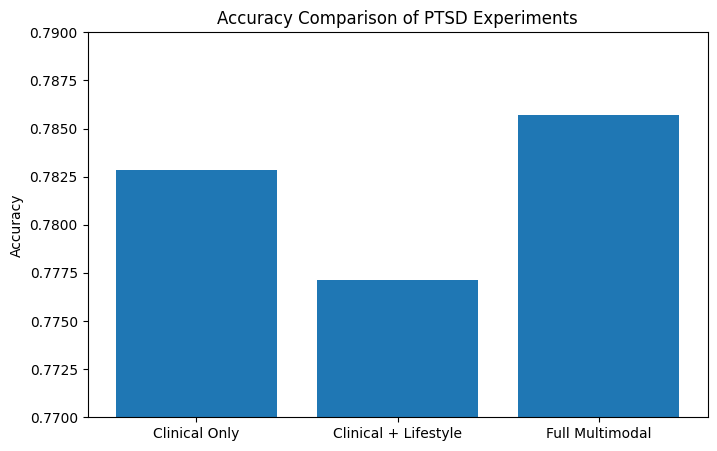

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(comparison['Experiment'], comparison['Best Accuracy'])
plt.ylim(0.77, 0.79) # Adjusted y-axis limits to show variation more clearly
plt.title('Accuracy Comparison of PTSD Experiments')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
best_pipeline = results_exp3['XGBoost']['pipeline']
X_test = results_exp3['XGBoost']['X_test']

/tmp/ipykernel_665/545924379.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


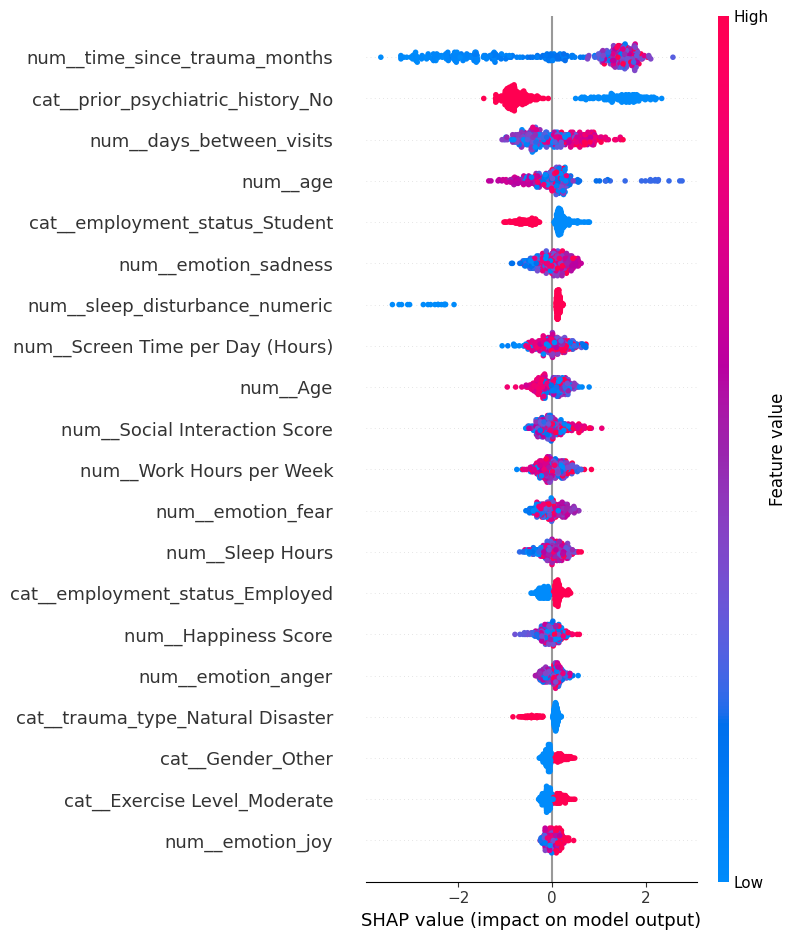

In [ ]:
preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['model']

X_test_processed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [ ]:
import joblib

joblib.dump(best_pipeline, 'ptsd_best_model.pkl')
print('Model saved successfully!')

Model saved successfully!


In [ ]:
sample = exp3.drop(columns=['ptsd_diagnosis']).iloc[[0]]

prediction = best_pipeline.predict(sample)
probability = best_pipeline.predict_proba(sample)

print('Prediction:', prediction)
print('Probability:', probability)

Prediction: [1]
Probability: [[0.00128782 0.9987122 ]]


In [ ]:
!ls /content

1_ptsd_class_distribution.png	 7_top5_features_pairplot.png
2_age_kde_by_ptsd.png		 Mental_Health_Lifestyle_Dataset.csv
3_gender_ptsd_grouped_bar.png	 ptsd_best_model.pkl
4_trauma_score_hist_by_ptsd.png  ptsd_clinical_dataset.xlsx
5_correlation_heatmap.png	 sample_data
6_lifestyle_boxplots.png


In [ ]:
from google.colab import files
files.download('/content/ptsd_best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>